<a href="https://colab.research.google.com/github/JackLGood/JackLGood.github.io/blob/main/Lab1_Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 - Diamond

Application: Diamond price

## Please specify below your group members, including their names, NetID, and UG/GR:
Double click to edit, press `Shift`+`Enter` to execute the block after editing

#### Member 1:
Name: Jack Good     NetID: jlg444     UG/G: Undergraduate
#### Member 2: (leave blank if submitting solo)
Name:      NetID:      UG/G:
#### Member 3: (leave blank if in group of 2)
Name:      NetID:      UG/G:

# 0. Decice which ML type to use in the following contexts

0.1 Training a computer program to play chess by letting it play against another instance of itself


**Answer:** Reinforced learning.

0.2 Predicting customer churns based on historical churn data


**Answer:** Supervised learning.

0.3 Identifying patterns in consumer behavior and form targeted marketing strategy


**Answer:** Unsupervised learning.

0.4 Forecasting sales under given pricing decisions


**Answer:** Supervised learning.

0.5 Discovering emerging topics on social media

**Answer:** Unsupervised learning.

0.6 Making sequential marketing decisions to attract new customers

**Answer:** Reinforced learning.

# 1. Overview and Data
Diamonds are often described by their "four C's": *carat*, *cut*, *color*, and *clarity*. In this lab, you will use linear regression to build a model that predicts the price of a diamond from some of these attributes.


The file `diamonds.csv` contains information on the attributes and price of a sample of 440 diamonds. Some of the variables included in the file are:

**carat**: weight of diamond (1 carat = 0.2 grams)

**cut**: a measure of a diamond's ability to transmit light (Fair, Good, Very Good, Premium, Ideal)

**clarity**: a measure of how many inclusions (flaws) a diamond has (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)

**z**: depth in mm

Please fill all the question marks (?) in this file. We start by reading in the data:

In [3]:
import pandas as pd
diamonds = pd.read_csv("diamonds.csv")
diamonds.head()

,carat,cut,color,clarity,table,x,y,z,price
0,0.90,Very Good,H,SI1,58.0,6.16,6.19,3.85,3595
1,0.30,Ideal,G,IF,56.0,4.34,4.36,2.68,863
2,0.70,Very Good,F,VS2,54.0,5.72,5.76,3.52,2928
3,0.55,Premium,E,SI2,58.0,5.35,5.33,3.19,1364
4,0.62,Premium,F,SI1,60.0,5.56,5.51,3.31,1766


# 2. Questions


**QUESTION 1:** We will first investigate how the depth of a diamond influences its price.

a) Create a scatterplot that visualizes how the price of diamonds depend on its depth, **z**.

Text(0, 0.5, 'Price')

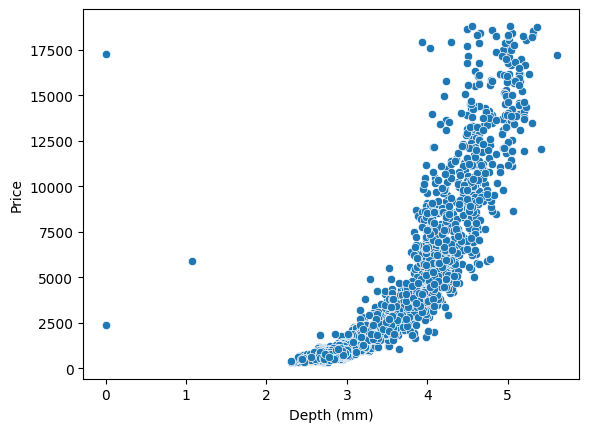

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data = diamonds, x = "z", y = "price")
plt.xlabel("Depth (mm)")
plt.ylabel("Price")

b) Build a simple regression model to predict **price** from **z**. Calculate the bias and weight using first order condition of SSE minimization
 $$\hat{w}_1=\frac{\sum_{i=1}^n x_i y_i-n \bar{x} \bar{y}}{\sum_{i=1}^n x_i^2-n \bar{x}^2}$$

In [5]:
import numpy as np
n = len(diamonds)
x = diamonds['z']
y = diamonds['price']
xy = 0
xx = 0
for i in range(n):
    xy = xy + x[i] * y[i]
    xx = xx + x[i] * x[i]

numerator = xy - n*np.mean(x)*np.mean(y)  #np.mean(x) takes mean value of x, which is x_bar in the formula
denominator = xx - n*(np.mean(x)**2)
w1_hat = numerator/denominator
print(w1_hat)
print("w1_hat is: ", round(w1_hat,2))

5008.567960432571
w1_hat is:  5008.57


and $$\widehat{w}_0=\bar{y}-\widehat{w}_1 \bar{x}$$

In [6]:
w0_hat = np.mean(y) - w1_hat * np.mean(x)
print("w0_hat is: ", round(w0_hat,2))

w0_hat is:  -13743.16


c) Now use `statsmodels` to build the regression model to predict **price** from **z**. How much of the variation in **price** is explained by **z**?

In [7]:
from statsmodels.formula.api import ols
model = ols("price ~ z", data=diamonds)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     7444.
Date:                Fri, 31 Jan 2025   Prob (F-statistic):               0.00
Time:                        01:25:09   Log-Likelihood:                -22604.
No. Observations:                2500   AIC:                         4.521e+04
Df Residuals:                    2498   BIC:                         4.522e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.374e+04    209.988    -65.447      0.0

**Answer:** Depth is a pretty good predictor of price in this model, as it accounts for nearly 75% of the price differences observed in the data. However, other factors also play a role in determining a diamond's price.

d) Use the fitted model to calculate SSE:
$$SSE=\sum_{i=1}^n\left(y_i-\widehat{y}_i\right)^2=\sum_{i=1}^n\left(y_i-\left(\widehat{w}_0+\widehat{w}_1 x_i\right)\right)^2$$
and then calculate $R^2=1-\frac{SSE}{SST}$

In [8]:
import numpy as np
y = diamonds['price']
y_hat = results.predict(diamonds['z'])
SSE = 0
for i in range(n):
    SSE = SSE + (y[i]-y_hat[i])**2
print("SSE is ", SSE)
SST = 0
for i in range(n):
    SST = SST + (y[i]-np.mean(y))**2
print("R_squared is", 1 - (SSE / SST))

SSE is  10447436959.210691
R_squared is 0.7487346184414865



e) Using your model, create a plot of predicted prices on the horizontal axis and actual (observed) prices on the vertical axis. Then, create a plot of predicted prices on the horizontal axis and residuals on the vertical axis.

Text(0, 0.5, 'Observed price')

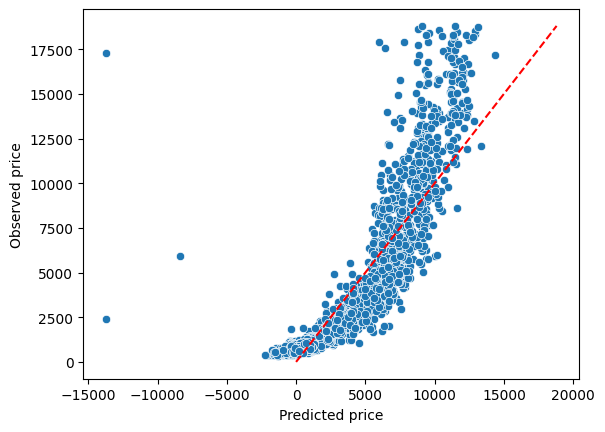

In [9]:
y_hat = results.predict(diamonds['z'])
plt.plot([0, max(diamonds['price'])], [0, max(diamonds['price'])],color = 'r', ls='--')
sns.scatterplot(x = y_hat, y= diamonds['price'] )
plt.xlabel("Predicted price")
plt.ylabel("Observed price")

Text(0, 0.5, 'Residuals')

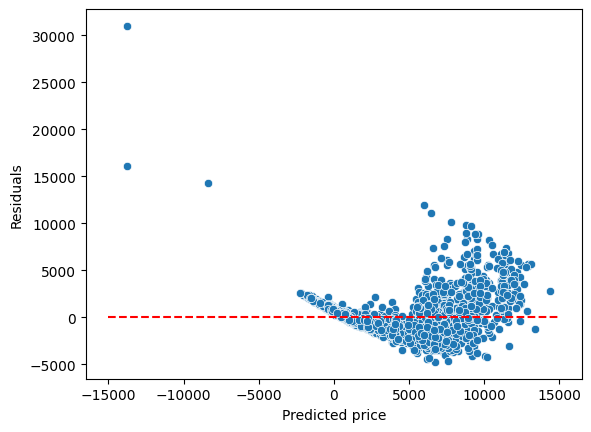

In [10]:
resid = diamonds['price'] - y_hat #define residuals
plt.plot([-15000, 15000], [0, 0],color = 'r', ls='--')
sns.scatterplot(x = y_hat,y = resid)
plt.xlabel("Predicted price")
plt.ylabel("Residuals")

f) Based on the plot above, identify two different issues when using this model to predict diamond prices.

**Answer:** the first plot of predicted prices and actual (observed) prices, showed that a linear prediction is probably not the best fit for this exponential function.

The spread of residuals increases as the predicted price increases. This would indicate that the model is less accurate at predicting prices for expensive diamonds compared to cheaper diamonds.


**QUESTION 2:** We will now investigate how the *weight* of a diamond influences its price.

a) Create a scatterplot that visualizes how the price of diamonds depend on **carat**.

Text(0, 0.5, 'Price')

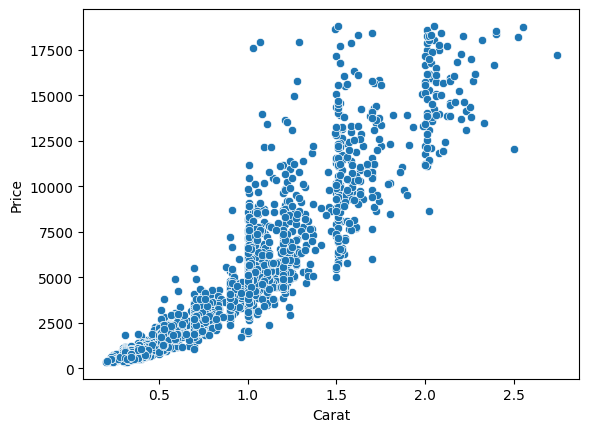

In [11]:
sns.scatterplot(data=diamonds, x="carat", y="price")
plt.xlabel("Carat")
plt.ylabel("Price")

b) Build a simple regression model to predict **price** from **carat**. How much of the variation in **price** is explained by **carat**?


In [12]:
model2 = ols("price ~ carat", data=diamonds)
results2 = model2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                 1.530e+04
Date:                Fri, 31 Jan 2025   Prob (F-statistic):               0.00
Time:                        01:26:21   Log-Likelihood:                -21876.
No. Observations:                2500   AIC:                         4.376e+04
Df Residuals:                    2498   BIC:                         4.377e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2380.8902     60.148    -39.584      0.0

**Answer:** The linear relationship between carat weight and price, as captured by your model, accounts for 86% of the observed differences in diamond prices within the dataset.

c) Interpret the coefficient for the **carat** variable in words. Does the model show more carat leads to higher price?

**Answer:** The coefficient for the carat is 7936.9504 which in essence is the slope of the linear prediction slope. For every one-unit increase in carat weight, the price of a diamond is predicted to increase by $7936.

d) Suppose you come across a new diamond with a weight of 0.8 carats. What does your model predict for its price?

In [13]:
print(results2.predict({"carat":0.8}))

0    3968.670132
dtype: float64


**Answer:** The predicted price is: 3968.670132.

e) Using your model, create a plot of predicted prices on the horizontal axis and actual prices on the vertical axis. Then, create a plot of predicted prices on the horizontal axis and residuals on the vertical axis.

Text(0, 0.5, 'Observed price')

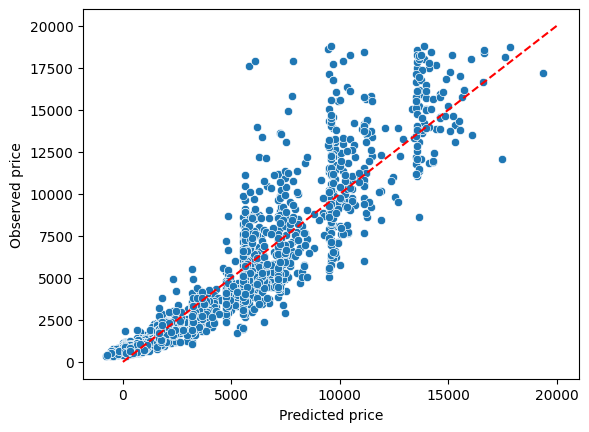

In [14]:
y_hat2 = results2.predict(diamonds['carat'])
plt.plot([0, 20000], [0, 20000],color = 'r', ls='--')
sns.scatterplot(x = y_hat2, y = diamonds['price'])
plt.xlabel("Predicted price")
plt.ylabel("Observed price")

Text(0, 0.5, 'Residuals')

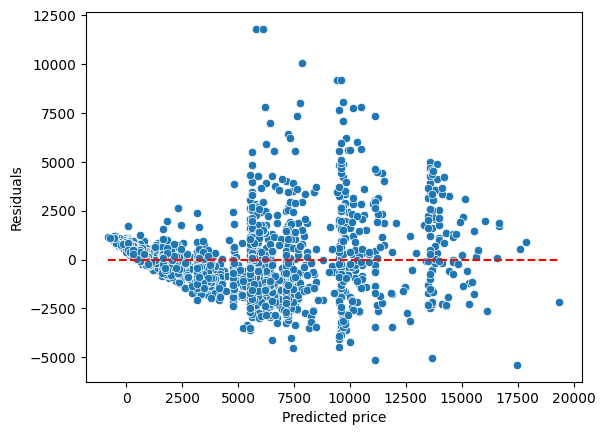

In [17]:
resid2 = diamonds['price'] - y_hat2
plt.plot([min(y_hat2), max(y_hat2)], [0, 0],color = 'r', ls='--')
sns.scatterplot(x = y_hat2, y = resid2)
plt.xlabel("Predicted price")
plt.ylabel("Residuals")

**QUESTION 3:** We will now investigate how clarity influences the price of a diamond. The highest clarity grade of a diamond is "flawless" and is indicated by an "IF" in the clarity column. Let's start by creating a subset of the data for just the "flawless" diamonds:

In [18]:
diamonds_IF = diamonds.loc[diamonds.clarity == 'IF']



a) The following code creates a plot of actual vs. predicted price for IF diamonds, using the model from Question 2. What does this tell you about that model's predictions for IF diamonds?

Text(0, 0.5, 'Observed price')

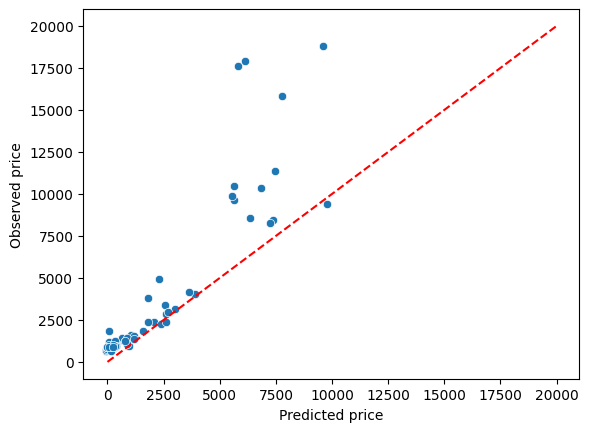

In [19]:
y_hat2_IF = results2.predict(diamonds_IF)
plt.plot([0, 20000], [0, 20000],color = 'r', ls='--')
sns.scatterplot(x = y_hat2_IF, y = diamonds['price'])
plt.xlabel("Predicted price")
plt.ylabel("Observed price")

**Answer:** The plot shows that the predicted line slope tends to fail as the carat weight increases, the model's linear predictions tend to underestimate the actual prices of "IF" diamonds, which seem to increase more rapidly (exponentially)

b) Build a simple regression model to predict **price** from **carat** for IF diamonds. Interpret the coefficient for the **carat** variable in words.


In [20]:
model_IF = ols("price ~ carat", data=diamonds_IF)
results_IF = model_IF.fit()
print(results_IF.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     336.2
Date:                Fri, 31 Jan 2025   Prob (F-statistic):           3.09e-29
Time:                        01:49:43   Log-Likelihood:                -679.88
No. Observations:                  76   AIC:                             1364.
Df Residuals:                      74   BIC:                             1368.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3185.6271    412.892     -7.715      0.0

**Answer:** The R-squared of 0.820 tells us that 82% of the variation in the price of "IF" clarity diamonds can be explained by the linear relationship with carat weight in the model. This indicates a strong positive correlation.

c) Recall the new diamond that you found, which had a weight of 0.8 carats. Suppose that diamond is IF. What does this model predict for its price? How does this compare to the prediction in Question 2 d).

In [21]:
price_hat = results_IF.predict({'carat':0.8})
print(price_hat)

0    6542.429637
dtype: float64


**Answer:** this model predicts the price to be 6542.429637. In 2d the predicted price was predicted price is: 3968.670132. This means the model referenced in this question expects a significantly higher price of a diamond compare to the other.